<a href="https://colab.research.google.com/github/francji1/01ZLMA/blob/main/code/01ZLMA_ex03_GLM_statistical_inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01ZLMA - Exercise 03

Exercise 03 of the course [01ZLMA](https://math.fel.cvut.cz/en/people/francji1/01ZLMA.html) - Generalized Linear Models.

## Contents

1. [Theory Recap from Lecture 04](#1-theory-recap-from-lecture-04)
   - 1.1 [Asymptotic Distributions](#11-asymptotic-distributions)
   - 1.2 [Saturated, Null, and Proposed Models](#12-saturated-null-and-proposed-models)
2. [IWLS Recap (Exercise from Last Week)](#2-iwls-recap-exercise-from-last-week)
   - 2.1 [Poisson GLM with Log Link](#21-poisson-glm-with-log-link)
   - 2.2 [IWLS Implementation](#22-iwls-implementation)
   - 2.3 [Asymptotic Properties of MLE](#23-asymptotic-properties-of-mle)
3. [Hypothesis Testing in GLM](#3-hypothesis-testing-in-glm)
4. [Wald Test](#4-wald-test)
   - 4.1 [Theory](#41-theory)
   - 4.2 [Manual Computation](#42-manual-computation)
   - 4.3 [Interpreting the Summary Table](#43-interpreting-the-summary-table)
   - 4.4 [Confidence Intervals for $\beta$](#44-confidence-intervals-for-beta)
5. [Deviance](#5-deviance)
   - 5.1 [Definition](#51-definition)
   - 5.2 [Deviance for Specific Distributions](#52-deviance-for-specific-distributions)
   - 5.3 [Manual Computation](#53-manual-computation)
   - 5.4 [Conditions for $\chi^2$ Approximation](#54-conditions-for-chi2-approximation)
6. [Likelihood Ratio Test (LRT)](#6-likelihood-ratio-test-lrt)
   - 6.1 [Theory](#61-theory)
   - 6.2 [Manual Computation](#62-manual-computation)
   - 6.3 [Using Anova Helper](#63-using-anova-helper)
7. [Score (Rao) Test](#7-score-rao-test)
   - 7.1 [Theory](#71-theory)
   - 7.2 [Manual Computation](#72-manual-computation)
   - 7.3 [Pearson Statistic](#73-pearson-statistic)
8. [Comparison: LM vs. GLM Inference](#8-comparison-lm-vs-glm-inference)
9. [Exercises](#9-exercises)


## Setup

In [2]:
import numpy as np
import scipy
from scipy import stats
from scipy.stats import chi2, norm
from scipy.special import gammaln

import statsmodels.api as sm
import statsmodels.formula.api as smf

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme()
np.random.seed(42)

In [3]:
import os
import sys

# Detect environment and load helpers accordingly
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q wget
    import wget
    url = "https://github.com/francji1/01ZLMA/raw/main/code/helpers.py"
    wget.download(url, '../content/helpers.py')
else:
    # Running locally: add the code directory to path
    helpers_dir = os.path.dirname(os.path.abspath('__file__'))
    if helpers_dir not in sys.path:
        sys.path.insert(0, helpers_dir)

from helpers import DiagnosticPlots, Anova

---
# 1. Theory Recap from Lecture 04

## 1.1 Asymptotic Distributions

Under the regularity conditions, the following asymptotic results hold for GLMs:

**Score vector:**

$$U(\beta) \dot{\sim} N_p(0, I(\beta))$$

equivalently: $I^{-1/2}(\beta)\, U(\beta) \stackrel{D}{\longrightarrow} N_p(0, \mathbb{I}_p)$ and $U^T(\beta) I^{-1}(\beta) U(\beta) \stackrel{D}{\longrightarrow} \chi^2(p)$.

**MLE and Wald statistic:**

$$\hat{\beta} \dot{\sim} N_p(\beta, I^{-1}(\beta))$$

equivalently: $(\hat{\beta} - \beta)^T I(\beta)(\hat{\beta} - \beta) \stackrel{D}{\longrightarrow} \chi^2(p)$.

**Consequences for individual parameters:**

Let $I^{-1}(\hat{\beta}) = (\vartheta_{jk})_{j,k=1}^p$. Then:
- $\text{Var}[\hat{\beta}_j] \approx \vartheta_{jj}$
- $\hat{\beta}_j \pm z_{1-\alpha/2} \sqrt{\vartheta_{jj}}$ is an asymptotic $100(1-\alpha)\%$ CI for $\beta_j$
- For testing $H_0: \beta_j = 0$:
  - $W = \frac{\hat{\beta}_j^2}{\vartheta_{jj}} \dot{\sim} \chi^2(1)$ (Wald statistic)
  - $Z = \frac{\hat{\beta}_j}{\sqrt{\vartheta_{jj}}} \dot{\sim} N(0,1)$ (equivalent Z-test)


## 1.2 Saturated, Null, and Proposed Models

| Model | Parameters | Description |
|-------|-----------|-------------|
| **Null model** | $p = 1$ | $\mu_i = \mu$ for all $i$. All variability attributed to random error. |
| **Proposed model** | $1 < p < n$ | $g(\mu_i) = x_i^T \beta$. Balance between fit and parsimony. |
| **Saturated model** | $p = n$ | $\hat{\mu}_i = y_i$ for all $i$. Perfect fit, no explanatory power. |

The saturated model has:
- Same distribution and link function as the proposed model
- Design matrix $X = \mathbb{I}_{n \times n}$ (identity matrix)
- MLE: $\tilde{\mu}_i = y_i$ (follows from likelihood equations)

**Key property:** The log-likelihood is maximized at the saturated model:
$$l(\tilde{\mu}, \phi; y) \geq l(\hat{\mu}, \phi; y) \geq l(\bar{y}, \phi; y)$$
(saturated $\geq$ proposed $\geq$ null)

**Questions:**
1. What is the difference between the null and saturated model?
2. Which model has the highest log-likelihood value?
3. What can you say about $\hat{\beta}$ and $U(\hat{\beta})$ for the saturated model?
4. Can the saturated model be used for prediction? Why or why not?


---
# 2. IWLS Recap (Exercise from Last Week)

## 2.1 Poisson GLM with Log Link

Generate synthetic data from a Poisson GLM with canonical **log link**:
- $N = n \times m = 40$ observations, $n = 20$, $m = 2$
- Design matrix with intercept and $\log(x_{2,i})$
- True regression coefficients $\beta = (0.9, 1.3)^T$
- $\lambda_i = e^{X_i \beta}$, $Y_i \sim \text{Poisson}(\lambda_i)$

### Theoretical Derivation (Poisson GLM)

| Component | Formula |
|-----------|---------|
| **Link** | $g(\lambda_i) = \log(\lambda_i) = X_i \beta$ |
| **Mean** | $\lambda_i = e^{X_i \beta}$ |
| **Log-likelihood** | $\ell(\beta) = \sum_{i} [Y_i (X_i \beta) - e^{X_i \beta} - \log(Y_i!)]$ |
| **Score** | $U(\beta) = X^T(Y - \mu)$, where $\mu_i = e^{X_i \beta}$ |
| **Fisher information** | $I(\beta) = X^T W X$, where $W = \text{diag}(\mu_i)$ |
| **IWLS update** | $(X^T W X) \beta^{(t+1)} = X^T W Z$ |
| **Adjusted response** | $Z = X\beta^{(t)} + \frac{Y - \mu}{\mu}$ |


In [4]:
# Data generation
np.random.seed(42)
n = 20  # number of unique x values
m = 2   # replication factor

X1 = np.ones(n * m)                                    # intercept
X2 = np.array(list(range(1, n + 1)) * m)               # covariate values
X  = np.vstack([X1, np.log(X2)]).T                      # design matrix [1, log(x2)]

beta_true = np.array([0.9, 1.3])                        # true regression coefficients
lambdas = np.exp(X @ beta_true)                          # true means
Y = np.random.poisson(lambdas, n * m)                    # response variable

d = pd.DataFrame({'Y': Y, 'X1': X1, 'X2': X2})
print(f"Data shape: {d.shape}")
d.head(10)

Data shape: (40, 3)


,Y,X1,X2
0,4,1.0,1
1,5,1.0,2
2,7,1.0,3
3,11,1.0,4
4,20,1.0,5
5,22,1.0,6
6,24,1.0,7
7,34,1.0,8
8,49,1.0,9
9,49,1.0,10


In [5]:
# Fit GLM using statsmodels (formula API)
model_formula = smf.glm(formula='Y ~ np.log(X2)', data=d, family=sm.families.Poisson()).fit()
print(model_formula.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      Y   No. Observations:                   40
Model:                            GLM   Df Residuals:                       38
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -125.77
Date:                Sun, 22 Mar 2026   Deviance:                       32.254
Time:                        10:49:47   Pearson chi2:                     32.2
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.7953      0.130      6.101      0.0

In [6]:
# Fit GLM using standard API (explicit design matrix)
model = sm.GLM(endog=Y, exog=X, family=sm.families.Poisson()).fit()
print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                   40
Model:                            GLM   Df Residuals:                       38
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -125.77
Date:                Sun, 22 Mar 2026   Deviance:                       32.254
Time:                        10:49:47   Pearson chi2:                     32.2
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7953      0.130      6.101      0.0

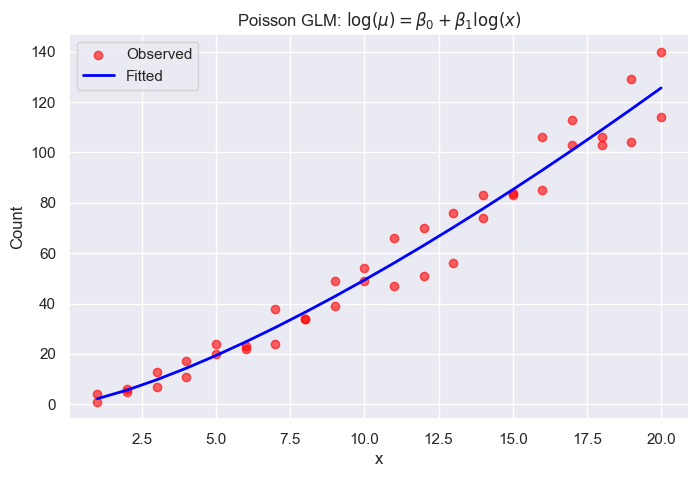

In [7]:
# Plot data and fitted values
beta_hat = model.params
y_hat = model.predict()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X2, Y, color='red', marker='o', alpha=0.6, label='Observed')
sort_idx = np.argsort(X2)
ax.plot(X2[sort_idx], y_hat[sort_idx], color='blue', linewidth=2, label='Fitted')
ax.set_title('Poisson GLM: $\\log(\\mu) = \\beta_0 + \\beta_1 \\log(x)$')
ax.set_xlabel('x')
ax.set_ylabel('Count')
ax.legend()
plt.show()

## 2.2 IWLS Implementation

Implement the IWLS (Iteratively Weighted Least Squares) algorithm manually and compare with `statsmodels`.


In [8]:
def calc_W(X, beta):
    '''Compute the weight matrix W = diag(mu) for Poisson GLM.'''
    mu = np.exp(X @ beta)
    return np.diag(mu)

def calc_Z(X, Y, beta):
    '''Compute the adjusted response Z = X*beta + (Y - mu)/mu for Poisson GLM.'''
    mu = np.exp(X @ beta)
    return X @ beta + (Y - mu) / mu

def IWLS(X, Y, beta_init, maxiter=100, epsilon=1e-8):
    '''IWLS for Poisson GLM with log link.
    Returns dict with: betas, FM (Fisher info), cov, n_iter'''
    beta = beta_init.copy()

    for i in range(1, maxiter + 1):
        W = calc_W(X, beta)
        Z = calc_Z(X, Y, beta)
        beta_new = np.linalg.solve(X.T @ W @ X, X.T @ W @ Z)

        if np.max(np.abs(beta_new - beta)) < epsilon:
            beta = beta_new
            break
        beta = beta_new

    W = calc_W(X, beta)
    FM = X.T @ W @ X
    cov = np.linalg.inv(FM)

    return {'betas': beta, 'FM': FM, 'cov': cov, 'n_iter': i}

In [9]:
# Run IWLS
result = IWLS(X, Y, beta_init=np.zeros(2))

print(f"IWLS converged in {result['n_iter']} iterations")
print(f"Parameter estimates:  {result['betas']}")
print(f"statsmodels estimates: {model.params}")
print(f"\nFisher information matrix:\n{result['FM']}")
print(f"\nEstimated covariance matrix:\n{result['cov']}")
print(f"statsmodels cov matrix:\n{np.array(model.cov_params())}")

IWLS converged in 94 iterations
Parameter estimates:  [0.79527673 1.34791687]
statsmodels estimates: [0.79527673 1.34791687]

Fisher information matrix:
[[ 2267.          5881.81010785]
 [ 5881.81010785 15667.31285084]]

Estimated covariance matrix:
[[ 0.01699076 -0.00637866]
 [-0.00637866  0.0024585 ]]
statsmodels cov matrix:
[[ 0.01699067 -0.00637863]
 [-0.00637863  0.00245849]]


## 2.3 Asymptotic Properties of MLE

Verify that $(\hat{\beta} - \beta) \dot{\sim} N_p(0, I^{-1}(\beta))$ by simulation:
- Generate data repeatedly for increasing sample sizes
- Check that the empirical covariance of $\hat{\beta}$ approaches $I^{-1}(\beta)$


In [10]:
# Monte Carlo verification of asymptotic normality
n_base = 10
n_rep = 100
n_obs_list = np.array([1, 2, 5, 10, 50, 200])
beta_true = np.array([0.9, 1.3])

betas_hat = np.zeros((len(n_obs_list), n_rep, 2))

for idx, mult in enumerate(n_obs_list):
    for j in range(n_rep):
        X1 = np.ones(n_base * mult)
        X2 = np.array(list(range(1, n_base + 1)) * mult)
        X_sim = np.vstack([X1, np.log(X2)]).T
        lambdas_sim = np.exp(X_sim @ beta_true)
        Y_sim = np.random.poisson(lambdas_sim)
        try:
            fit = sm.GLM(endog=Y_sim, exog=X_sim, family=sm.families.Poisson()).fit()
            betas_hat[idx, j] = fit.params
        except:
            betas_hat[idx, j] = [np.nan, np.nan]

In [11]:
# Display convergence of empirical covariance to theoretical
print("Empirical covariance of (beta_hat - beta) for increasing n:\n")
for i, mult in enumerate(n_obs_list):
    valid = ~np.isnan(betas_hat[i, :, 0])
    diff = betas_hat[i, valid] - beta_true
    emp_cov = np.cov(diff.T)
    emp_bias = np.mean(diff, axis=0)
    print(f"n = {n_base * mult:5d}: bias = [{emp_bias[0]:+.4f}, {emp_bias[1]:+.4f}], "
          f"Var(beta0) = {emp_cov[0,0]:.6f}, Var(beta1) = {emp_cov[1,1]:.6f}")

Empirical covariance of (beta_hat - beta) for increasing n:

n =    10: bias = [+0.0010, +0.0033], Var(beta0) = 0.121888, Var(beta1) = 0.030367
n =    20: bias = [-0.0216, +0.0106], Var(beta0) = 0.034144, Var(beta1) = 0.008980
n =    50: bias = [+0.0229, -0.0110], Var(beta0) = 0.018202, Var(beta1) = 0.004509
n =   100: bias = [-0.0157, +0.0054], Var(beta0) = 0.008261, Var(beta1) = 0.002081
n =   500: bias = [-0.0033, +0.0014], Var(beta0) = 0.001794, Var(beta1) = 0.000509
n =  2000: bias = [-0.0001, +0.0003], Var(beta0) = 0.000428, Var(beta1) = 0.000109


---
# 3. Hypothesis Testing in GLM

In GLM, we use three fundamental test statistics to compare models and test hypotheses about parameters. All are based on the **likelihood function** and are **asymptotically equivalent** under $H_0$.

| Test | Based on | Requires fitting | Distribution under $H_0$ |
|------|----------|-----------------|--------------------------|
| **Wald** | MLE $\hat{\beta}$ under $H_1$ | Full model only | $\chi^2(q)$ |
| **LRT** | Log-likelihood difference | Both models | $\chi^2(q)$ |
| **Score (Rao)** | Score at $\hat{\beta}_0$ | Reduced model only | $\chi^2(q)$ |

where $q = p - p_0$ is the difference in number of parameters.

**Key difference from Linear Models:**
- LM: exact $t$ and $F$ distributions (finite sample)
- GLM: **asymptotic** $N(0,1)$ and $\chi^2$ distributions (large sample approximations)

We will now derive and compute each test manually on our Poisson GLM example, then verify with `statsmodels`.


---
# 4. Wald Test

## 4.1 Theory

The Wald test is based on the asymptotic normality of the MLE $\hat{\beta}$.

**For a single parameter** $H_0: \beta_j = 0$:

$$Z = \frac{\hat{\beta}_j}{\sqrt{\vartheta_{jj}}} \dot{\sim} N(0,1), \qquad W = Z^2 = \frac{\hat{\beta}_j^2}{\vartheta_{jj}} \dot{\sim} \chi^2(1)$$

where $\vartheta_{jj}$ is the $j$-th diagonal element of $I^{-1}(\hat{\beta})$.

**For multiple parameters** $H_0: \beta_1 = 0$ (testing $q$ parameters simultaneously):

$$W = \hat{\beta}_1^T \, I_{11}(\hat{\beta}) \, \hat{\beta}_1 \dot{\sim} \chi^2(q)$$

where $I_{11}$ is the submatrix of $I(\hat{\beta})$ corresponding to the parameters being tested.

**Important:** The Wald test only requires fitting the **full (unrestricted) model** $M$ under $H_1$.

**Known vs. unknown $\phi$:**
- If $\phi$ is known (Poisson, Binomial): use $\chi^2$ / $N(0,1)$
- If $\phi$ is unknown (Normal, Gamma): replace $\phi$ with $\hat{\phi} = D/(n-p)$, use $F(q, n-p)$ / $t(n-p)$
  (This case will be covered in Exercise 04)


## 4.2 Manual Computation

In [12]:
# Fit the models
model_full = sm.GLM(Y, X, family=sm.families.Poisson()).fit()
model_null = sm.GLM(Y, X[:, [0]], family=sm.families.Poisson()).fit()

print("Full model parameters:", model_full.params)
print("Covariance matrix:\n", np.array(model_full.cov_params()))
print()

# --- Wald test for individual parameters ---
# Z-statistic: Z_j = beta_hat_j / sqrt(Var(beta_hat_j))
cov_matrix = np.array(model_full.cov_params())
z_stats = model_full.params / np.sqrt(np.diag(cov_matrix))
p_values_wald = 2 * norm.sf(np.abs(z_stats))

print("=== Wald Test (individual parameters) ===")
for j in range(len(model_full.params)):
    print(f"  beta_{j}: Z = {z_stats[j]:.4f}, p-value = {p_values_wald[j]:.6f}")

# Verify: these should match model.tvalues and model.pvalues
print(f"\n  statsmodels Z-values: {model_full.tvalues}")
print(f"  statsmodels p-values: {model_full.pvalues}")
print(f"  Match: {np.allclose(z_stats, model_full.tvalues)}")

Full model parameters: [0.79527673 1.34791687]
Covariance matrix:
 [[ 0.01699067 -0.00637863]
 [-0.00637863  0.00245849]]

=== Wald Test (individual parameters) ===
  beta_0: Z = 6.1012, p-value = 0.000000
  beta_1: Z = 27.1850, p-value = 0.000000

  statsmodels Z-values: [ 6.10116835 27.18499329]
  statsmodels p-values: [1.05295932e-009 9.77311342e-163]
  Match: True


In [13]:
# --- Joint Wald test (all parameters) ---
# W = beta_hat^T * I(beta_hat) * beta_hat ~ chi2(p)
W_joint = model_full.params @ np.linalg.inv(cov_matrix) @ model_full.params
p_value_joint = chi2.sf(W_joint, len(model_full.params))

print("=== Joint Wald Test (all parameters simultaneously) ===")
print(f"  W = {W_joint:.4f}, df = {len(model_full.params)}, p-value = {p_value_joint:.6f}")

# --- Wald test for beta_1 only (testing H0: beta_1 = 0) ---
W_beta1 = z_stats[1]**2
p_value_beta1 = chi2.sf(W_beta1, 1)
print(f"\n=== Wald Test for beta_1 (slope) ===")
print(f"  W = Z^2 = {W_beta1:.4f}, df = 1, p-value = {p_value_beta1:.6f}")

=== Joint Wald Test (all parameters simultaneously) ===
  W = 42509.6516, df = 2, p-value = 0.000000

=== Wald Test for beta_1 (slope) ===
  W = Z^2 = 739.0239, df = 1, p-value = 0.000000


## 4.3 Interpreting the Summary Table

The `summary()` output from `statsmodels` GLM contains Wald test results:

| Column | Meaning |
|--------|---------|
| `coef` | MLE $\hat{\beta}_j$ |
| `std err` | $\sqrt{\vartheta_{jj}}$ = standard error from $I^{-1}(\hat{\beta})$ |
| `z` | $Z = \hat{\beta}_j / \text{SE}(\hat{\beta}_j)$ -- the Wald Z-statistic |
| `P>\|z\|` | Two-sided p-value from $N(0,1)$ |
| `[0.025, 0.975]` | 95% Wald confidence interval |

For Poisson and Binomial GLMs ($\phi = 1$ known), the Z-test is appropriate.
For Normal and Gamma GLMs ($\phi$ unknown), `statsmodels` still reports Z-tests by default -- but the correct test would use $t(n-p)$. This is handled via the `scale` parameter (see Exercise 04).


In [14]:
print(model_full.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                   40
Model:                            GLM   Df Residuals:                       38
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -125.77
Date:                Sun, 22 Mar 2026   Deviance:                       32.254
Time:                        10:49:48   Pearson chi2:                     32.2
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7953      0.130      6.101      0.0

## 4.4 Confidence Intervals for $\beta$

The asymptotic $100(1-\alpha)\%$ CI for $\beta_j$:

$$\hat{\beta}_j \pm z_{1-\alpha/2} \sqrt{\vartheta_{jj}}$$


In [15]:
# Manual CI computation
alpha = 0.05
z_crit = norm.ppf(1 - alpha / 2)  # 1.96

for j in range(len(model_full.params)):
    se_j = np.sqrt(cov_matrix[j, j])
    ci_lo = model_full.params[j] - z_crit * se_j
    ci_hi = model_full.params[j] + z_crit * se_j
    print(f"beta_{j}: {model_full.params[j]:.4f}  "
          f"95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]")

print(f"\nstatsmodels CI:\n{model_full.conf_int()}")

beta_0: 0.7953  95% CI: [0.5398, 1.0508]
beta_1: 1.3479  95% CI: [1.2507, 1.4451]

statsmodels CI:
[[0.53979882 1.05075464]
 [1.25073574 1.44509801]]


---
# 5. Deviance

## 5.1 Definition

The **scaled deviance** measures the discrepancy between the fitted model and the saturated model:

$$S(y, \hat{\mu}, \phi) = 2 \left[ l(\tilde{\mu}, \phi; y) - l(\hat{\mu}, \phi; y) \right] = 2 \sum_{i=1}^{n} \frac{y_i (\tilde{\theta}_i - \hat{\theta}_i) - \left( b(\tilde{\theta}_i) - b(\hat{\theta}_i) \right)}{a_i(\phi)}$$

where $\tilde{\mu}_i = y_i$ (saturated model MLE) and $\hat{\mu}_i$ is the proposed model MLE.

If $a_i(\phi) = a_i \phi$, then $S = D / \phi$, where the **(unscaled) deviance** is:

$$D(y, \hat{\mu}) = 2 \sum_{i=1}^{n} \frac{y_i (\tilde{\theta}_i - \hat{\theta}_i) - \left( b(\tilde{\theta}_i) - b(\hat{\theta}_i) \right)}{a_i}$$

**Properties of $D$:**
1. $D \geq 0$, and $D = 0$ iff the model fits perfectly ($\hat{\mu}_i = y_i$)
2. $D$ does not depend on $\phi$
3. For the Normal model: $D = \text{SSE} = \sum (y_i - \hat{\mu}_i)^2$ (deviance generalizes residual sum of squares)
4. Under the model: $S(y, \hat{\mu}, \phi) \dot{\sim} \chi^2(n - p)$ (approximately)

**Warning:** The $\chi^2(n-p)$ approximation for deviance is **not always reliable** for testing model adequacy. It works well for comparing two models (deviance difference), but not for absolute goodness-of-fit testing.


## 5.2 Deviance for Specific Distributions

| Distribution | Deviance $D(y, \hat{\mu})$ |
|:---:|:---|
| **Normal** | $\displaystyle\sum_{i=1}^{n} (y_i - \hat{\mu}_i)^2$ |
| **Poisson** | $\displaystyle 2 \sum_{i=1}^{n} \left[ y_i \log\frac{y_i}{\hat{\mu}_i} - (y_i - \hat{\mu}_i) \right]$ |
| **Binomial** | $\displaystyle 2 \sum_{i=1}^{n} \left[ y_i \log\frac{y_i}{\hat{\mu}_i} + (n_i - y_i) \log\frac{n_i - y_i}{n_i - \hat{\mu}_i} \right]$ |
| **Gamma** | $\displaystyle 2 \sum_{i=1}^{n} \left[ -\log\frac{y_i}{\hat{\mu}_i} + \frac{y_i - \hat{\mu}_i}{\hat{\mu}_i} \right]$ |
| **Inv. Gaussian** | $\displaystyle \sum_{i=1}^{n} \frac{(y_i - \hat{\mu}_i)^2}{y_i \hat{\mu}_i^2}$ |

Note: For Poisson, since $\sum y_i = \sum \hat{\mu}_i$ (MLE property), the deviance simplifies to $D = 2 \sum y_i \log(y_i / \hat{\mu}_i)$.


## 5.3 Manual Computation

In [16]:
# --- Manual deviance computation for Poisson GLM ---
mu_hat = model_full.predict()

# Full formula (including the -(y - mu) term)
mask = Y > 0  # avoid log(0)
D_manual = 2 * np.sum(Y[mask] * np.log(Y[mask] / mu_hat[mask]) - (Y[mask] - mu_hat[mask]))
# For y_i = 0: contribution is 2*(0 - (0 - mu_hat_i)) = 2*mu_hat_i
D_manual += 2 * np.sum(mu_hat[~mask])

print(f"Manual deviance:      {D_manual:.6f}")
print(f"statsmodels deviance: {model_full.deviance:.6f}")
print(f"Match: {np.isclose(D_manual, model_full.deviance)}")

Manual deviance:      32.254408
statsmodels deviance: 32.254408
Match: True


In [17]:
# --- Log-likelihood computation ---
# For Poisson: l = sum(y*log(mu) - mu - log(y!))
ll_manual = np.sum(Y * np.log(mu_hat) - mu_hat - gammaln(Y + 1))

print(f"Manual log-likelihood:      {ll_manual:.6f}")
print(f"statsmodels log-likelihood: {model_full.llf:.6f}")
print(f"Match: {np.isclose(ll_manual, model_full.llf)}")

# --- Pearson chi-squared ---
X2_pearson = np.sum((Y - mu_hat)**2 / mu_hat)
print(f"\nManual Pearson X^2:      {X2_pearson:.6f}")
print(f"statsmodels Pearson X^2: {model_full.pearson_chi2:.6f}")

Manual log-likelihood:      -125.766609
statsmodels log-likelihood: -125.766609
Match: True

Manual Pearson X^2:      32.232218
statsmodels Pearson X^2: 32.232218


## 5.4 Conditions for $\chi^2$ Approximation

The approximation $S(y, \hat{\mu}, \phi) \dot{\sim} \chi^2(n-p)$ works well when:

| Distribution | Condition |
|:---:|:---|
| **Normal** | Exact (not approximate) |
| **Binomial** | $\min_i\{y_i\} \geq 3$ and $\min_i\{n_i - y_i\} \geq 3$ |
| **Poisson** | $\min_i\{y_i\} \geq 3$ |
| **Gamma** | $\phi < 1/3$ |

**Practical implication:** For binary data ($n_i = 1$) or Poisson data with many zeros, the deviance is **not** a good absolute measure of model fit. However, **deviance differences** (comparing two nested models) remain valid -- this is the LRT.


In [18]:
# Check deviance as a GOF test for our Poisson model
p_dev = chi2.sf(model_full.deviance, df=model_full.df_resid)
chi2_crit = chi2.isf(0.05, model_full.df_resid)

print(f"Residual deviance: {model_full.deviance:.4f}")
print(f"df_resid:          {model_full.df_resid}")
print(f"chi2 critical (5%): {chi2_crit:.4f}")
print(f"p-value:           {p_dev:.4f}")
print(f"Conclusion: {'Reject H0 (poor fit)' if p_dev < 0.05 else 'Do not reject H0 (adequate fit)'}")

# Check condition: min(y) >= 3?
print(f"\nCondition check: min(Y) = {Y.min()}")
if Y.min() < 3:
    print("Warning: min(Y) < 3 -- chi-square approximation for deviance may be unreliable!")

Residual deviance: 32.2544
df_resid:          38
chi2 critical (5%): 53.3835
p-value:           0.7317
Conclusion: Do not reject H0 (adequate fit)

Condition check: min(Y) = 1


---
# 6. Likelihood Ratio Test (LRT)

## 6.1 Theory

The LRT compares two nested models $M_0 \subset M$ using the deviance difference:

**When $\phi$ is known** (Poisson, Binomial):
$$T_1 = \frac{D_0 - D}{\phi} \dot{\sim} \chi^2(p - p_0) \quad \text{under } H_0$$

Since $\phi = 1$ for Poisson: $T_1 = D_0 - D$.

**When $\phi$ is unknown** (Normal, Gamma):
$$T_2 = \frac{(D_0 - D) / (p - p_0)}{D / (n - p)} \dot{\sim} F(p - p_0, n - p) \quad \text{under } H_0$$

(The F-test version will be covered in Exercise 04.)

**Equivalently**, in terms of log-likelihoods:
$$\text{LRT} = 2 \left[ l(\hat{\mu}, \phi; y) - l(\hat{\mu}_0, \phi; y) \right] = \frac{D_0 - D}{\phi} \dot{\sim} \chi^2(p - p_0)$$

**Comparison with saturated model** (goodness-of-fit):
$$D / \phi = 2 \left[ l(\tilde{\mu}, \phi; y) - l(\hat{\mu}, \phi; y) \right] \dot{\sim} \chi^2(n - p)$$
(This is the deviance test from Section 5.)


## 6.2 Manual Computation

In [19]:
# LRT: Full model vs. Null model
# H0: beta_1 = 0 (slope is zero)
D_full = model_full.deviance
D_null = model_null.deviance
df_diff = model_null.df_resid - model_full.df_resid

LRT_stat = D_null - D_full  # phi = 1 for Poisson
LRT_pval = chi2.sf(LRT_stat, df_diff)

print("=== Likelihood Ratio Test: Full vs. Null ===")
print(f"  D(null)  = {D_null:.4f},  df = {model_null.df_resid}")
print(f"  D(full)  = {D_full:.4f},  df = {model_full.df_resid}")
print(f"  LRT stat = D_null - D_full = {LRT_stat:.4f}")
print(f"  df       = {df_diff}")
print(f"  p-value  = {LRT_pval:.6f}")

# Equivalently via log-likelihoods
LRT_ll = 2 * (model_full.llf - model_null.llf)
print(f"\n  Via log-likelihoods: 2*(l_full - l_null) = {LRT_ll:.4f}")
print(f"  Match: {np.isclose(LRT_stat, LRT_ll)}")

=== Likelihood Ratio Test: Full vs. Null ===
  D(null)  = 1189.1526,  df = 39
  D(full)  = 32.2544,  df = 38
  LRT stat = D_null - D_full = 1156.8982
  df       = 1
  p-value  = 0.000000

  Via log-likelihoods: 2*(l_full - l_null) = 1156.8982
  Match: True


## 6.3 Using the Anova Helper

In [20]:
anova = Anova()

# Sequential analysis (Type I)
print("=== Sequential Deviance Table ===")
display(anova(model_full))

=== Sequential Deviance Table ===


,resid_df,resid_deviance,df,deviance,chi2,p_val
x0,39,1189.152570,NaN,NaN,NaN,NaN
x1,38,32.254408,1.0,1156.898162,1156.898162,1.421262e-253


In [21]:
# LRT comparing two specific models
print("=== LRT: Null vs. Full ===")
display(anova(model_null, model_full, test="LRT"))

=== LRT: Null vs. Full ===


,resid_df,resid_deviance,df,deviance,chi2,p_val
0,39,1189.152570,NaN,NaN,NaN,NaN
1,38,32.254408,1.0,1156.898162,1156.898162,1.421262e-253


In [22]:
# Chi-squared test (same as LRT for phi=1)
print("=== Chi-squared test ===")
display(anova(model_full, test="Chisq"))

=== Chi-squared test ===


,resid_df,resid_deviance,df,deviance,chi2,p_val
x0,39,1189.152570,NaN,NaN,NaN,NaN
x1,38,32.254408,1.0,1156.898162,1156.898162,1.421262e-253


---
# 7. Score (Rao) Test

## 7.1 Theory

The Score (Rao) test evaluates whether the score function $U(\beta)$ is significantly different from zero when evaluated at the **restricted** MLE $\hat{\beta}_0$ (under $H_0$).

**For testing model adequacy** (proposed model vs. saturated model):

$$R_n(\hat{\mu}, \phi) = U^T(\hat{\mu}) \, I^{-1}(\hat{\mu}) \, U(\hat{\mu}) \dot{\sim} \chi^2(n - p) \quad \text{under } H_0$$

where:
- $U(\mu) = \left( \frac{\partial l}{\partial \mu_1}, \ldots, \frac{\partial l}{\partial \mu_n} \right)^T$ is the score vector of the **saturated model**
- $I(\mu)$ is the Fisher information matrix of the saturated model
- Both are evaluated at $\hat{\mu} = \mu(\hat{\beta})$ from the **proposed model**

**For testing a submodel** $M_0 \subset M$ (testing $H_0: \beta_1 = 0$):

The Score test evaluates the score of the full model at the restricted estimates. Only the **reduced model** needs to be fitted.

**Advantage:** Computationally efficient -- only requires fitting the simpler model.

**Relation to Pearson statistic:** For exponential family GLMs, the Rao score statistic for model adequacy simplifies to the **generalized Pearson statistic**:

$$X^2 = \sum_{i=1}^{n} \frac{(y_i - \hat{\mu}_i)^2}{\text{Var}(Y_i)} \dot{\sim} \chi^2(n-p)$$


## 7.2 Manual Computation

In [23]:
# --- Score test: testing whether log(X2) should be added to the null model ---
# Fit only the REDUCED model (null), then evaluate the score of the full model

mu_null = model_null.mu  # fitted values under H0

# Score vector component for the omitted variable X[:,1] = log(X2)
# For Poisson: U_j = sum( x_ij * (y_i - mu_i) )
score_beta1 = X[:, 1] @ (Y - mu_null)

# Fisher information for the omitted variable (under H0)
# I_11 = sum( x_ij^2 * mu_i ) for Poisson
I_11 = np.sum(X[:, 1]**2 * mu_null)

# Score statistic
score_stat = score_beta1**2 / I_11
score_pval = chi2.sf(score_stat, 1)

print("=== Score (Rao) Test: Should log(X2) be added? ===")
print(f"  Score vector component: U = {score_beta1:.4f}")
print(f"  Fisher info component:  I = {I_11:.4f}")
print(f"  Score statistic: R = U^2/I = {score_stat:.4f}")
print(f"  df = 1")
print(f"  p-value = {score_pval:.6f}")

=== Score (Rao) Test: Should log(X2) be added? ===
  Score vector component: U = 1083.0680
  Fisher info component:  I = 11580.3754
  Score statistic: R = U^2/I = 101.2952
  df = 1
  p-value = 0.000000


In [24]:
# Built-in score test in statsmodels
score_result = model_null.score_test(X[:, [1]])
print(f"statsmodels score test: statistic = {score_result[0].item():.4f}, "
      f"p-value = {score_result[1].item():.6f}")

statsmodels score test: statistic = 824.6358, p-value = 0.000000


## 7.3 Pearson Statistic

The **Pearson (generalized) chi-squared statistic** tests model adequacy:

$$X^2 = \sum_{i=1}^{n} \frac{(y_i - \hat{\mu}_i)^2}{V(\hat{\mu}_i)} \dot{\sim} \chi^2(n - p)$$

where $V(\mu_i) = b''(\theta_i)$ is the variance function. For Poisson: $V(\mu) = \mu$.

**Relation to other statistics:**
- $X^2$ is the Rao score statistic for model adequacy (proposed vs. saturated model)
- For the Normal model, $X^2 = \text{SSE}$ (same as deviance)
- For other families, $X^2 \neq D$ in general, but both converge to $\chi^2(n-p)$

Also related is the **Mahalanobis statistic**:
$$M_n(y, \hat{\mu}, \phi) = (y - \hat{\mu})^T I(\hat{\mu}) (y - \hat{\mu}) \dot{\sim} \chi^2(n-p)$$


In [25]:
# Pearson X^2 as GOF test
X2 = np.sum((Y - mu_hat)**2 / mu_hat)
p_pearson = chi2.sf(X2, model_full.df_resid)

print("=== Pearson Goodness-of-Fit Test ===")
print(f"  Pearson X^2 = {X2:.4f}")
print(f"  df           = {model_full.df_resid}")
print(f"  p-value      = {p_pearson:.4f}")
print(f"  Conclusion: {'Reject (poor fit)' if p_pearson < 0.05 else 'Do not reject (adequate fit)'}")

print(f"\n  Compare with deviance: D = {model_full.deviance:.4f}, "
      f"p = {chi2.sf(model_full.deviance, model_full.df_resid):.4f}")
print(f"  Pearson X^2 from model: {model_full.pearson_chi2:.4f}")

=== Pearson Goodness-of-Fit Test ===
  Pearson X^2 = 32.2322
  df           = 38
  p-value      = 0.7326
  Conclusion: Do not reject (adequate fit)

  Compare with deviance: D = 32.2544, p = 0.7317
  Pearson X^2 from model: 32.2322


In [26]:
# Using Anova helper for Rao test
I_n = np.diag(np.ones(n * m))
model_sat = sm.GLM(endog=Y, exog=I_n, family=sm.families.Poisson()).fit()

display(anova(model_full, model_sat, test="Rao"))

c:\Users\Ruslanidze\ZLMA\.venv\Lib\site-packages\statsmodels\regression\_tools.py:121: RuntimeWarning: divide by zero encountered in scalar divide
  scale = np.dot(wresid, wresid) / df_resid
c:\Users\Ruslanidze\ZLMA\.venv\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\Ruslanidze\ZLMA\helpers.py:169: UserWarning: Note that rao score statistic may be inccorect. Currently it is Generalized Pearson statistic
  warnings.warn("Note that rao score statistic may be inccorect. Currently it is Generalized Pearson statistic")


,resid_df,resid_deviance,df,deviance,rao,p_val
0,38,3.225441e+01,NaN,NaN,NaN,NaN
1,0,7.105427e-14,38.0,32.254408,32.232218,0.732643


In [27]:
# --- Side-by-side comparison of all three tests ---
print("=" * 65)
print("  Comparison: Testing H0: beta_1 = 0 (no effect of log(X2))")
print("=" * 65)

# Wald
W = z_stats[1]**2
p_wald = chi2.sf(W, 1)

# LRT
LRT = D_null - D_full
p_lrt = chi2.sf(LRT, 1)

# Score
S = score_stat
p_score = score_pval

print(f"{'Test':<12} {'Statistic':>12} {'df':>5} {'p-value':>12}")
print("-" * 45)
print(f"{'Wald':<12} {W:>12.4f} {'1':>5} {p_wald:>12.6f}")
print(f"{'LRT':<12} {LRT:>12.4f} {'1':>5} {p_lrt:>12.6f}")
print(f"{'Score':<12} {S:>12.4f} {'1':>5} {p_score:>12.6f}")
print("-" * 45)
print("All three tests are asymptotically equivalent under H0.")
print("Differences reflect finite-sample behavior.")

  Comparison: Testing H0: beta_1 = 0 (no effect of log(X2))
Test            Statistic    df      p-value
---------------------------------------------
Wald             739.0239     1     0.000000
LRT             1156.8982     1     0.000000
Score            101.2952     1     0.000000
---------------------------------------------
All three tests are asymptotically equivalent under H0.
Differences reflect finite-sample behavior.


---
# 9. Exercises

## Exercise 1: Poisson GLM with Identity Link

1. Generate data with the following parameters:
   - $Y \sim \text{Poi}(\mu_i)$, where $\mu_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2}$, i.e., identity link: $g(\mu_i) = \mu_i = x_i^T \beta = \eta_i$
   - $X_{i1} \sim N(50, 10)$
   - $X_{i2} \sim U(10, 60)$
   - $X_{i3} \sim \text{Ber}(0.45)$ (noise variable)
   - $n = 40$

2. Fit the saturated, null, "full" (with all 3 predictors), and "best" models.

3. For each model, compute:
   - Fitted values $\hat{\mu}_i$
   - Deviance $D$
   - Pearson $X^2$

4. Compare the "full" model with the "best" model using:
   - Wald test
   - LRT (deviance difference)
   - Score (Rao) test

## Exercise 2: Monte Carlo Verification

Generate 100 datasets for $n \in \{20, 40, 60, 80, 100\}$ and:
1. Plot $(\hat{\beta}_i - \beta_i)$ vs. $n$ -- verify convergence
2. For each dataset, compute the Wald, LRT, and Score statistics for $H_0: \beta_1 = 0$
3. Make QQ-plots of the test statistics against $\chi^2(1)$ -- verify the asymptotic distribution


### Exercise 1

In [ ]:
X1 = np.random.normal(50, 10, size=40)
X2 = np.random.uniform(10, 60, size=40)
X3 = np.random.binomial(n=1,p=0.45, size=40)

beta_0 = 0.9
beta_1 = 1.3
beta_2 = 0.9

lambdas = beta_0 + beta_1 * X1 + beta_2 * X2
assert lambdas.min() > 0, "Některé lambdy jsou záporné!" # mu je kladné, protože používáme identitu jako link funkci

Y = np.random.poisson(lambdas)

In [33]:
import warnings
warnings.filterwarnings("ignore")

X_sat = np.eye(40)
X_null = np.ones((40, 1))
X_best = np.column_stack([X_null, X1, X2])
X_full = np.column_stack([X_null, X1, X2, X3])

model_sat = sm.GLM(endog=Y, exog=X_sat, family=sm.families.Poisson(link=sm.families.links.Identity())).fit()
model_null = sm.GLM(endog=Y, exog=X_null, family=sm.families.Poisson(link=sm.families.links.Identity())).fit()
model_best = sm.GLM(endog=Y, exog=X_best, family=sm.families.Poisson(link=sm.families.links.Identity())).fit()
model_full = sm.GLM(endog=Y, exog=X_full, family=sm.families.Poisson(link=sm.families.links.Identity())).fit()

In [42]:
def Deviance(model):
    mu_hat = model.mu
    term = np.where(Y > 0, Y * np.log(Y / mu_hat), 0)  
    return 2 * np.sum(term - (Y - mu_hat))

def Chi_squared(model):
    mu_hat = model.mu
    return np.sum((Y - mu_hat)**2 / mu_hat)

# Compare deviance and Pearson chi-squared for all models
print("Model comparison:")
print("Saturated Model:")

print(Deviance(model_sat))
print(model_sat.deviance)

print(Chi_squared(model_sat))
print(model_sat.pearson_chi2)

print("\nNull Model:")
print(Deviance(model_null))
print(model_null.deviance)

print(Chi_squared(model_null))
print(model_null.pearson_chi2)

print("\nBest Model (X1, X2):")
print(Deviance(model_best))
print(model_best.deviance)

print(Chi_squared(model_best))
print(model_best.pearson_chi2)

print("\nFull Model (X1, X2, X3):")
print(Deviance(model_full))
print(model_full.deviance)

print(Chi_squared(model_full))
print(model_full.pearson_chi2)

Model comparison:
Saturated Model:
1.365574320288942e-13
1.365574320288942e-13
2.972120588789685e-29
2.972120588789685e-29

Null Model:
211.69833122262463
211.69833122262463
208.65796669152374
208.65796669152374

Best Model (X1, X2):
41.89273812491342
41.89273812491342
42.26331340005274
42.26331340005274

Full Model (X1, X2, X3):
41.816569999671955
41.816569999671955
42.15607181248125
42.15607181248125


In [43]:
def Wald_test(model_full, param_num):                               # vezme pouze jeden model a pta se, jestli je beta_3 (koeficient pro X3) roven nule
    beta_hat = model_full.params[param_num]                         # je posledni ve vektoru s odyhady
    var_beta_hat = model_full.cov_params()[param_num, param_num]    # variance je posledni diagonalni prvek covariance matrix
    w_beta = beta_hat**2 / var_beta_hat                             # Wald statistic pro beta_3
    return w_beta, chi2.sf(w_beta, 1)                               # p-hodnota testu, 1 je stupen volnosti pro test beta_3 (jeden parametr)

def LRT_test(model_reduced, model_full):                                 # vezme dva modely a poropna je pomocí LRT testu
    df = model_reduced.df_resid - model_full.df_resid
    stat = model_reduced.deviance - model_full.deviance
    return stat, chi2.sf(stat, df)

def Score_test(model, Y, X):                                        # vezme pouze jeden model a pta se, jestli by se mela pridat promenna X[:,3]
    mu = model.mu
    score = X[:, 3] @ (Y - mu)
    Fisher = np.sum(X[:, 3]**2 * mu)
    stat = score**2 / Fisher
    return stat,  chi2.sf(stat, 1)

In [44]:
print("Wald:", Wald_test(model_full, 3))
print("LRT:", LRT_test(model_best, model_full))
print("Score:", Score_test(model_best, Y, X_full))

Wald: (np.float64(0.07585913488976337), np.float64(0.7829894544619271))
LRT: (np.float64(0.0761681252414661), np.float64(0.7825590236680755))
Score: (np.float64(0.05451623624910821), np.float64(0.8153831682157591))


### Velka p-hodnota => nemam dost dukazu z dat, ze X3 je ruzne od nuly => v tomto pripade to je jenom sumovy parametr

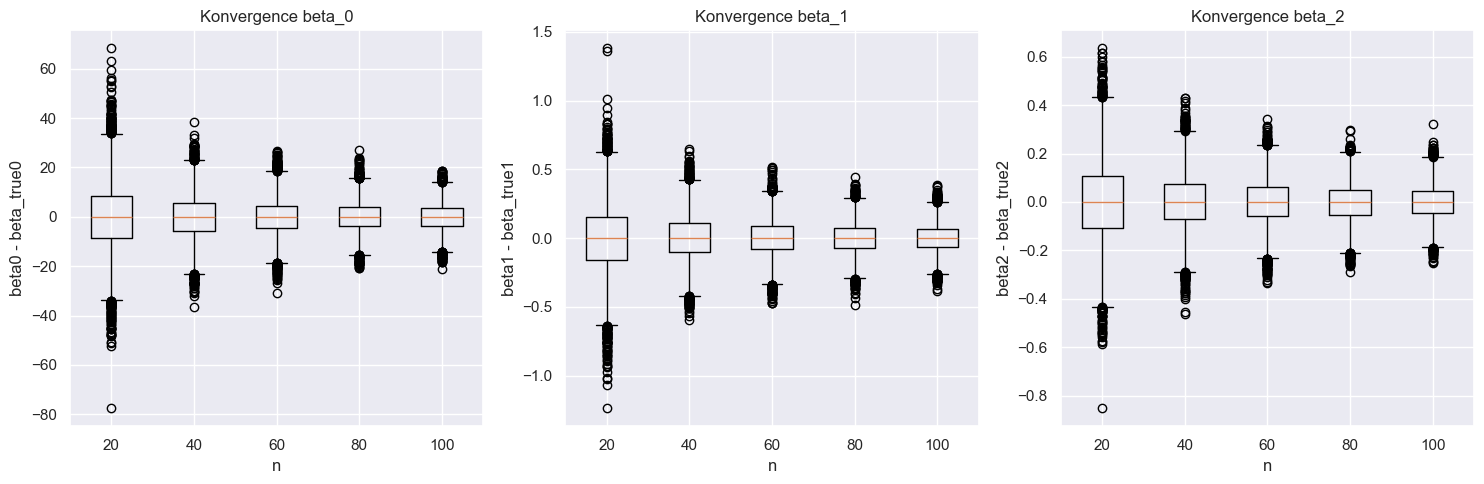

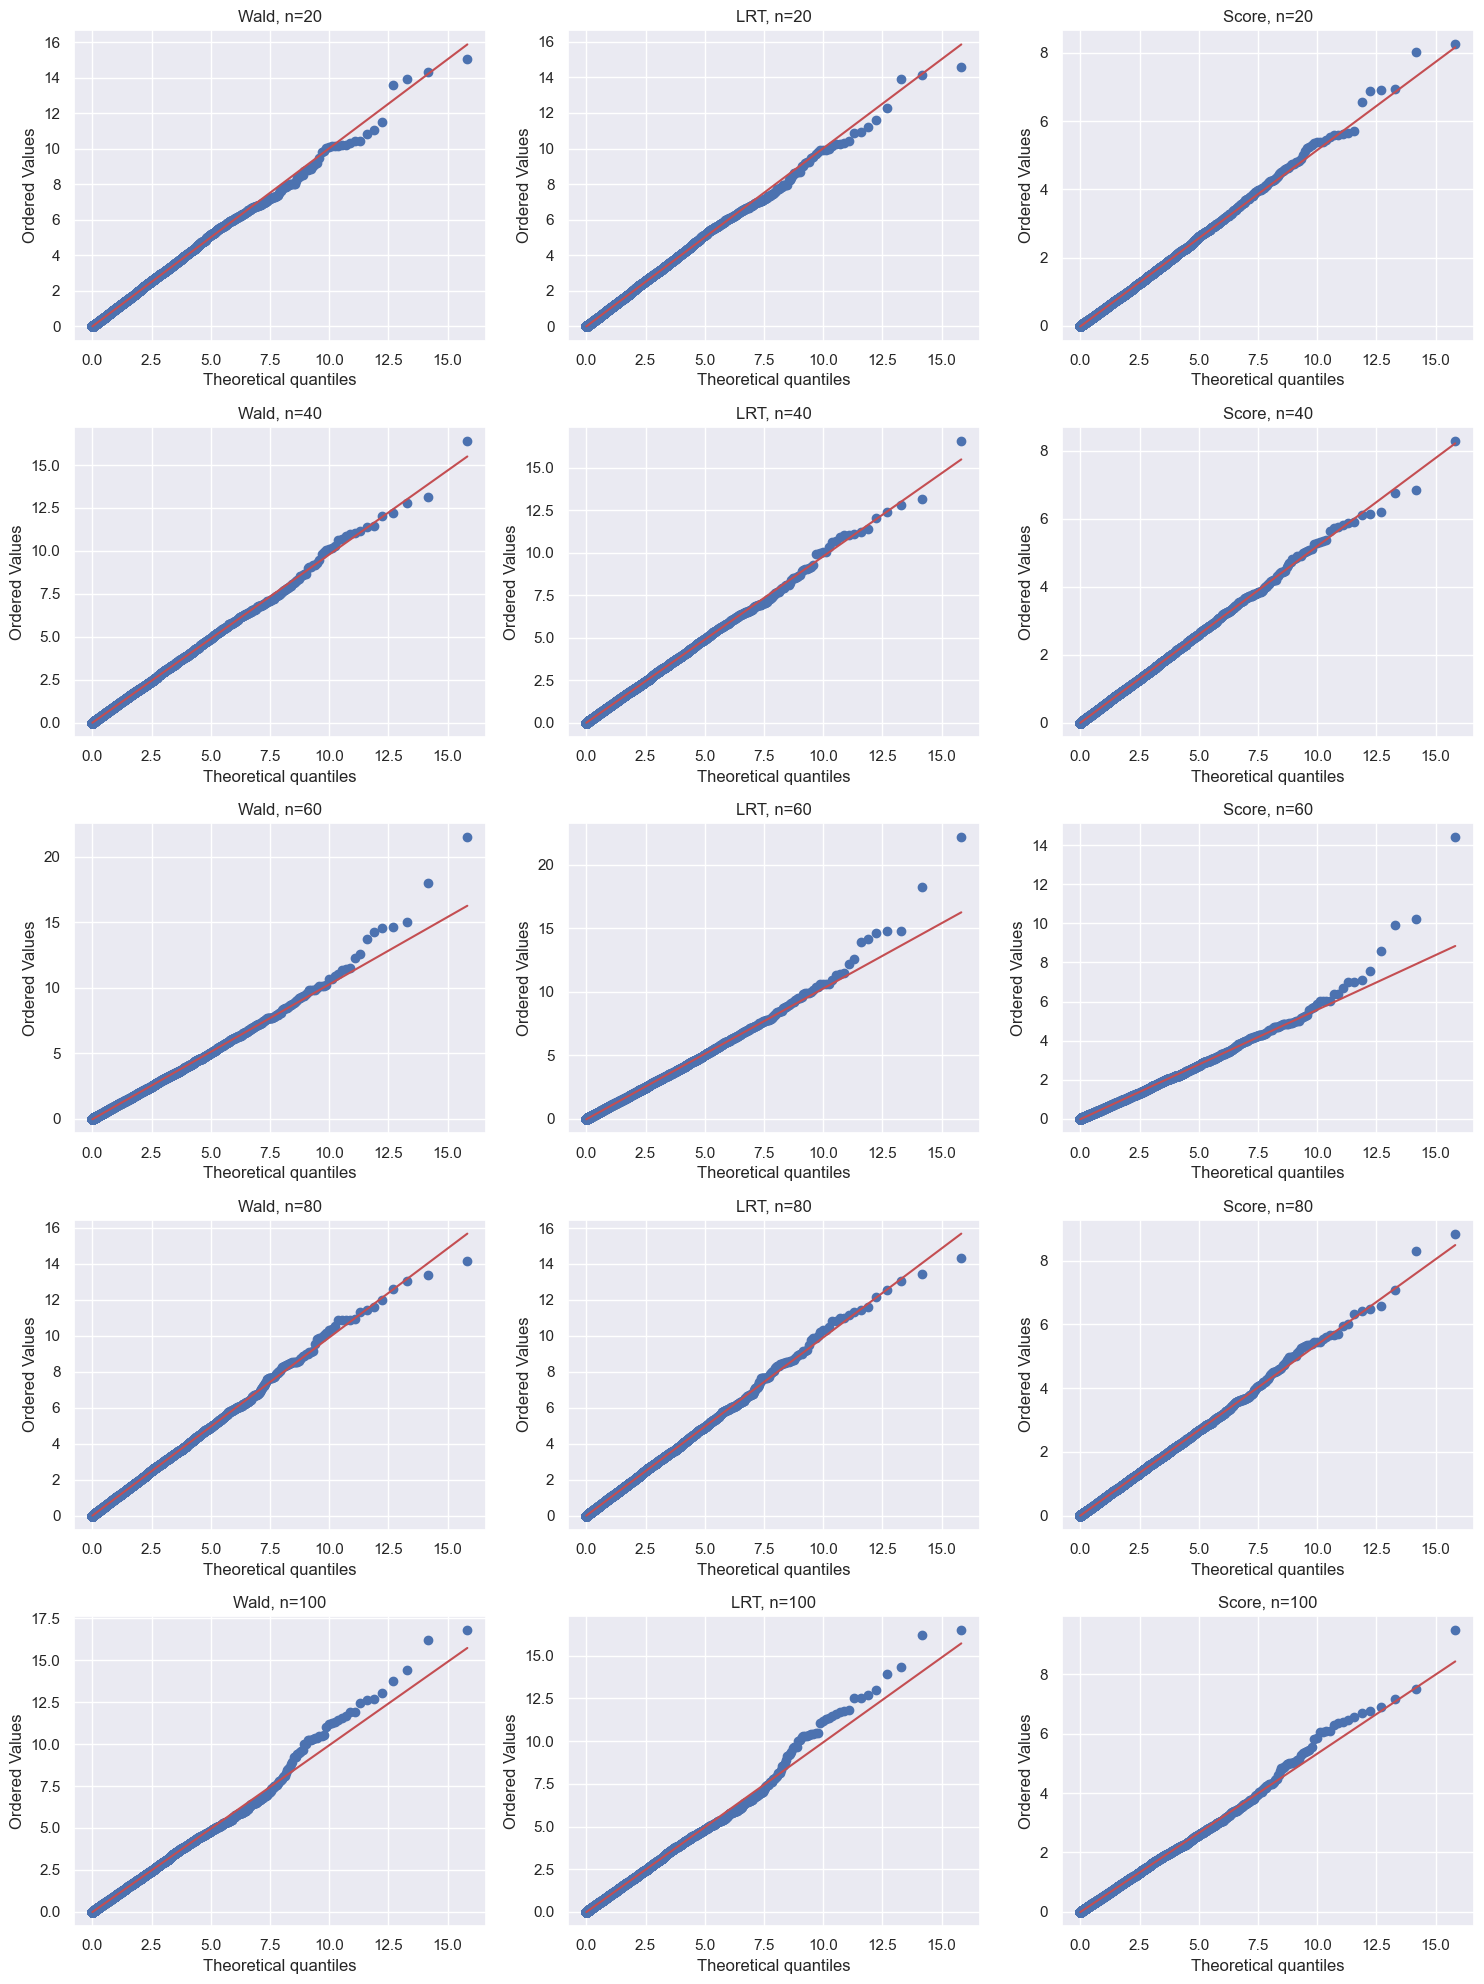

In [52]:
n_list = [20, 40, 60, 80, 100]
n_reps = 10000
beta_true = np.array([beta_0, beta_1, beta_2])

hist_beta_diff = np.zeros((len(n_list), n_reps, 3))  # 3 parametry (beta_0, beta_1, beta_2)
hist_wald = np.zeros((len(n_list), n_reps))
hist_LRT = np.zeros((len(n_list), n_reps))
hist_score = np.zeros((len(n_list), n_reps))

for idx, n in enumerate(n_list):
    for i in range(n_reps):

        # vygenerujeme data pro n pozorovani
        X1 = np.random.normal(50, 10, size=n)
        X2 = np.random.uniform(10, 60, size=n)
        X3 = np.random.binomial(n=1,p=0.45, size=n)

        # vytvoříme design matice pro oba modely
        X_null = np.ones((n, 1))
        X_best = np.column_stack([X_null, X1, X2])
        X_full = np.column_stack([X_null, X1, X2, X3])
        
        # vygenerujeme Y podle modelu
        lambdas = beta_0 + beta_1 * X1 + beta_2 * X2
        Y = np.random.poisson(lambdas)

        # fitneme oba modely a uložíme odhady
        model_best = sm.GLM(endog=Y, exog=X_best, family=sm.families.Poisson(link=sm.families.links.Identity())).fit()

        model_full = sm.GLM(endog=Y, exog=X_full, family=sm.families.Poisson(link=sm.families.links.Identity())).fit()

        # ukladame odhady a testy pro beta_3 (koeficient pro X3) z obou modelu
        hist_beta_diff[idx, i] = model_best.params - beta_true
        hist_wald[idx, i] = Wald_test(model_full, 3)[0]
        hist_LRT[idx, i] = LRT(model_best, model_full)[0]
        hist_score[idx, i] = Score_test(model_best, Y, X_full)[0]


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
beta_names = ['beta_0', 'beta_1', 'beta_2']

for j in range(3):
    axes[j].boxplot([hist_beta_diff[idx, :, j] for idx in range(len(n_list))], labels=n_list)
    axes[j].set_xlabel('n')
    axes[j].set_ylabel(f'beta{j} - beta_true{j}')
    axes[j].set_title(f'Konvergence {beta_names[j]}')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(n_list), 3, figsize=(15, 20))
test_names = ['Wald', 'LRT', 'Score']
test_data = [hist_wald, hist_LRT, hist_score]

for idx, n in enumerate(n_list):
    for j, (name, data) in enumerate(zip(test_names, test_data)):
        stats.probplot(data[idx], dist=chi2(df=1), plot=axes[idx, j])
        axes[idx, j].set_title(f'{name}, n={n}')

plt.tight_layout()
plt.show()
        

### Cervena primnka jsou skutecne kvantilz chi-kvadrat a modre body jsou vypocitane z mych simulaci. 
### Z teorie vime, ze Waldovy, LRT a Rao-Score statistiky se blizi k chi-kvadrat pro rostoucim n
### Pokud body vic a vic lezi na primce => plati 